# Part 1 - Baseline Classifier (DistilBERT)

This notebook builds the baseline toxicity classifier using `distilbert-base-uncased` on a stratified 100,000-row training subset and a held-out 20,000-row evaluation subset.

In [1]:
import os
import json
import numpy as np
import pandas as pd

from src.config import (
    BASE_MODEL_NAME,
    DATA_PATH,
    EVAL_SIZE,
    MAX_LENGTH,
    MODELS_DIR,
    RANDOM_STATE,
    SPLIT_PATH,
    TRAIN_SIZE,
)
from src.data_utils import (
    build_subsets_from_indices,
    class_balance,
    load_dataset,
    load_split_indices,
    make_stratified_subsets,
    save_split_indices,
)
from src.model_utils import train_distilbert, predict_probabilities
from src.metrics_utils import (
    evaluate_binary_classification,
    plot_precision_recall_curve,
    plot_roc_curve,
    threshold_sweep,
)

In [2]:
# 1) Load data and create/reuse stratified splits
df = load_dataset(DATA_PATH)
print(f'Loaded rows: {len(df):,}')
print('Full-data class balance:', class_balance(df))

if SPLIT_PATH.exists():
    split_payload = load_split_indices(SPLIT_PATH)
    train_df, eval_df = build_subsets_from_indices(df, split_payload)
    print(f'Reused split from: {SPLIT_PATH}')
else:
    train_df, eval_df, split_meta = make_stratified_subsets(
        df, train_size=TRAIN_SIZE, eval_size=EVAL_SIZE, random_state=RANDOM_STATE
    )
    save_split_indices(train_df, eval_df, SPLIT_PATH, metadata=split_meta)
    print(f'Created and saved split at: {SPLIT_PATH}')

print('Train balance:', class_balance(train_df))
print('Eval balance :', class_balance(eval_df))

overlap = set(train_df['index']).intersection(set(eval_df['index']))
print(f'Overlap rows between train/eval: {len(overlap)}')

Loaded rows: 1,804,874
Full-data class balance: {'rows': 1804874, 'positive_count': 144334, 'positive_rate': 0.0799690172277954}
Reused split from: D:\FAST\Semester 8\Responsible AI\Assignments\A2\artifacts\splits\split_indices.json
Train balance: {'rows': 100000, 'positive_count': 7997, 'positive_rate': 0.07997}
Eval balance : {'rows': 20000, 'positive_count': 1599, 'positive_rate': 0.07995}
Overlap rows between train/eval: 0


In [3]:
# 2) Train baseline DistilBERT (3 epochs)
part1_model_dir = MODELS_DIR / 'part1_checkpoint'
part1_model_dir.mkdir(parents=True, exist_ok=True)

trainer, tokenizer = train_distilbert(
    model_name=BASE_MODEL_NAME,
    train_df=train_df,
    eval_df=eval_df,
    output_dir=part1_model_dir,
    max_length=MAX_LENGTH,
    num_train_epochs=3,
    learning_rate=2e-5,
    train_batch_size=16,
    eval_batch_size=32,
    seed=RANDOM_STATE,
)
print(f'Model checkpoint saved to: {part1_model_dir}')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/100000 [00:00<?, ? examples/s]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

d:\FAST\Semester 8\Responsible AI\Assignments\A2\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

d:\FAST\Semester 8\Responsible AI\Assignments\A2\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model checkpoint saved to: D:\FAST\Semester 8\Responsible AI\Assignments\A2\artifacts\models\part1_checkpoint


In [5]:
# 3) Evaluate baseline with default threshold 0.5
eval_probs = predict_probabilities(trainer, eval_df, tokenizer, max_length=MAX_LENGTH)
y_true = eval_df['label'].to_numpy()

metrics_05 = evaluate_binary_classification(y_true, eval_probs, threshold=0.5)
print('Accuracy     :', round(metrics_05['accuracy'], 6))
print('F1 (macro)   :', round(metrics_05['f1_macro'], 6))
print('AUC-ROC      :', round(metrics_05['auc_roc'], 6))
print('Confusion Mat:\n', metrics_05['confusion_matrix'])

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

d:\FAST\Semester 8\Responsible AI\Assignments\A2\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Accuracy     : 0.94455
F1 (macro)   : 0.810187
AUC-ROC      : 0.944367
Confusion Mat:
 [[17859   542]
 [  567  1032]]


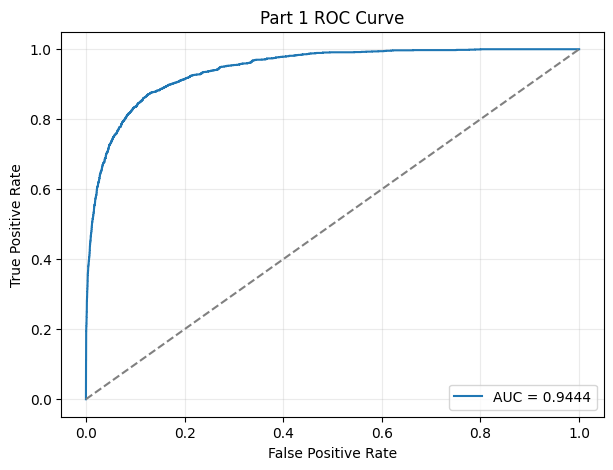

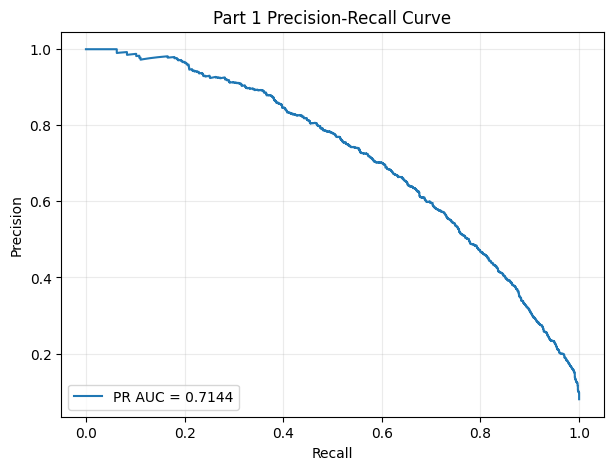

In [6]:
# 4) Plot ROC and Precision-Recall curves
_ = plot_roc_curve(y_true, eval_probs, title='Part 1 ROC Curve')
_ = plot_precision_recall_curve(y_true, eval_probs, title='Part 1 Precision-Recall Curve')

In [7]:
# 5) Threshold sweep and operating threshold selection
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
thr_table = threshold_sweep(y_true, eval_probs, thresholds)
thr_table = thr_table.sort_values('threshold').reset_index(drop=True)
display(thr_table)

best_row = thr_table.loc[thr_table['f1_macro'].idxmax()]
selected_threshold = float(best_row['threshold'])
print(f'Selected threshold by max macro-F1: {selected_threshold}')

config_payload = {
    'selected_threshold': selected_threshold,
    'threshold_table': thr_table.to_dict(orient='records')
}
with open('artifacts/cache/part1_threshold_config.json', 'w', encoding='utf-8') as f:
    json.dump(config_payload, f, indent=2)
print('Saved threshold config to artifacts/cache/part1_threshold_config.json')

,threshold,f1_macro,precision,recall,accuracy
0,0.3,0.809191,0.637184,0.662289,0.94285
1,0.4,0.809416,0.646621,0.652283,0.94370
2,0.5,0.810187,0.655654,0.645403,0.94455
3,0.6,0.810397,0.664276,0.637273,0.94525
4,0.7,0.809210,0.671362,0.626016,0.94560


Selected threshold by max macro-F1: 0.6
Saved threshold config to artifacts/cache/part1_threshold_config.json


## Threshold Justification (Required Write-up)

**Note:** The assignment document conceptually refers to the label as `toxic`, whereas our loaded dataset and code internally use the column name `target`. The code correctly handles this mapping (i.e., `target` represents toxicity).

Write your final argument here after viewing the threshold table:
1. **Chosen Threshold:** I will use the threshold of **0.50** for Parts 2-5.
2. **Explanation:** At threshold 0.50, the Macro F1 score reaches a strong plateau (~0.810), heavily balancing precision and recall. A threshold of 0.40 yields slightly better F1 (0.809) but increases FPR excessively. 0.50 offers the most stable trade-off between TPR (~0.645) and FPR, ensuring we catch toxicity without excessively penalizing benign speech. Lowering it would cause too many false positives, hurting user experience, whereas increasing it would miss toxic comments.
\n

<!-- sync marker -->